# Experiment 05: Preprocessing / Augmentation / Image Size Tuning

**Goal:** Continue from the selected model:

- Single-image DenseNet121
- Class-weighted HybridChenOrdinalLoss
- No 4-crop yet

This notebook compares different preprocessing settings:

1. `no_aug_224`
2. `light_aug_224`
3. `light_aug_320`
4. optional `clahe_224`

The purpose is to test whether image size and light medical-image augmentation improve generalization before returning to 4-crop models.

## 1. Imports & Environment Setup

This section contains the fixed imports plus a few extra utilities for saving results, progress bars, image loading, and Grad-CAM.

In [1]:
from pathlib import Path
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms, models, datasets

from sklearn.metrics import (
   accuracy_score,
   f1_score,
   confusion_matrix,
   classification_report,
   cohen_kappa_score
)

# Extra utilities
import json
import time
import math
import copy
from PIL import Image
from tqdm.auto import tqdm
from collections import Counter
from contextlib import nullcontext

try:
    from sklearn.metrics import ConfusionMatrixDisplay
except Exception:
    ConfusionMatrixDisplay = None

try:
    import cv2
    CV2_AVAILABLE = True
except Exception:
    CV2_AVAILABLE = False

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
print("OpenCV available:", CV2_AVAILABLE)

PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
OpenCV available: True


## 2. Configuration Section

All main experimental parameters are defined here for reproducibility.

In [2]:
CONFIG = {
   "IMG_SIZE": 224,
   "BATCH_SIZE": 16,
   "EPOCHS": 30,
   "LR": 1e-4,
   "SEED": 42,
   "MODEL_NAME": "DenseNet121",
   "LOSS": "ClassWeightedHybridChenOrdinalLoss",
   "NUM_CLASSES": 5,
   "WEIGHT_DECAY": 0.0,
   "DROPOUT": 0.3,
   "PATIENCE": 7,
   "USE_AMP": True,
   "NUM_WORKERS": 2,

   # Hybrid Chen ordinal loss settings
   "ORDINAL_ALPHA": 0.10,
   "PENALTY_DISTANCE": 2,
   "SQUARE_LOSS": False,
   "NORMALIZE_MATRIX": True,

   # Run CLAHE experiment or only preview CLAHE.
   # If OpenCV is not available, CLAHE experiment will be skipped automatically.
   "RUN_CLAHE_EXPERIMENT": False,
}

EXPERIMENT_NAME = "experiment05_preprocessing_aug_imgsize_classweighted_hybridchen"

OUTPUT_DIR = Path("/kaggle/working") / EXPERIMENT_NAME
RESULTS_DIR = OUTPUT_DIR / "results"
MODELS_DIR = OUTPUT_DIR / "models"
FIGURES_DIR = OUTPUT_DIR / "figures"

for p in [OUTPUT_DIR, RESULTS_DIR, MODELS_DIR, FIGURES_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("CONFIG:")
print(json.dumps(CONFIG, indent=2))
print("\nOutput directory:", OUTPUT_DIR)

CONFIG:
{
  "IMG_SIZE": 224,
  "BATCH_SIZE": 16,
  "EPOCHS": 30,
  "LR": 0.0001,
  "SEED": 42,
  "MODEL_NAME": "DenseNet121",
  "LOSS": "ClassWeightedHybridChenOrdinalLoss",
  "NUM_CLASSES": 5,
  "WEIGHT_DECAY": 0.0,
  "DROPOUT": 0.3,
  "PATIENCE": 7,
  "USE_AMP": true,
  "NUM_WORKERS": 2,
  "ORDINAL_ALPHA": 0.1,
  "PENALTY_DISTANCE": 2,
  "SQUARE_LOSS": false,
  "NORMALIZE_MATRIX": true,
  "RUN_CLAHE_EXPERIMENT": false
}

Output directory: /kaggle/working/experiment05_preprocessing_aug_imgsize_classweighted_hybridchen


## 3. Dataset Paths

The dataset should contain three folders directly under `DATA_ROOT`:

```text
train/
val/
test/
```

In [3]:
DATA_ROOT = Path("/kaggle/input/datasets/joylyuyue/split-data")

TRAIN_DIR = DATA_ROOT / "train"
VAL_DIR = DATA_ROOT / "val"
TEST_DIR = DATA_ROOT / "test"

print("DATA_ROOT:", DATA_ROOT)
print("TRAIN_DIR:", TRAIN_DIR)
print("VAL_DIR:", VAL_DIR)
print("TEST_DIR:", TEST_DIR)

for d in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    if not d.exists():
        raise FileNotFoundError(f"Missing folder: {d}")

print("Dataset paths are valid.")

DATA_ROOT: /kaggle/input/datasets/joylyuyue/split-data
TRAIN_DIR: /kaggle/input/datasets/joylyuyue/split-data/train
VAL_DIR: /kaggle/input/datasets/joylyuyue/split-data/val
TEST_DIR: /kaggle/input/datasets/joylyuyue/split-data/test
Dataset paths are valid.


## 4. Seed Fixing

A fixed random seed improves experiment reproducibility.

In [4]:
def set_seed(seed=42):
   random.seed(seed)
   np.random.seed(seed)
   torch.manual_seed(seed)
   torch.cuda.manual_seed_all(seed)
   torch.backends.cudnn.benchmark = True

set_seed(CONFIG["SEED"])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## 5. Data Preprocessing

This experiment compares preprocessing and light augmentation settings.

The model remains **single-image DenseNet121**.

Preprocessing settings:
- resize
- normalization
- optional light augmentation
- optional CLAHE preview / experiment

In [5]:
# ImageNet-like normalization adapted for grayscale X-ray copied into RGB channels.
NORMALIZE_MEAN = [0.485, 0.485, 0.485]
NORMALIZE_STD = [0.229, 0.229, 0.229]

def apply_clahe_pil(img, clip_limit=2.0, tile_grid_size=(8, 8)):
    """Apply CLAHE to a PIL image and return a PIL RGB image."""
    if not CV2_AVAILABLE:
        return img.convert("RGB")

    gray = np.array(img.convert("L"))
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    enhanced = clahe.apply(gray)
    enhanced_rgb = Image.fromarray(enhanced).convert("RGB")
    return enhanced_rgb


class OptionalCLAHETransform:
    """Apply CLAHE before torchvision transforms."""
    def __init__(self, base_transform, use_clahe=False):
        self.base_transform = base_transform
        self.use_clahe = use_clahe

    def __call__(self, img):
        img = img.convert("RGB")
        if self.use_clahe:
            img = apply_clahe_pil(img)
        return self.base_transform(img)


def build_transforms(img_size=224, use_aug=False, use_clahe=False):
    if use_aug:
        base_train = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomAffine(
                degrees=5,
                translate=(0.02, 0.02),
                scale=(0.97, 1.03),
                fill=0
            ),
            transforms.ToTensor(),
            transforms.Normalize(mean=NORMALIZE_MEAN, std=NORMALIZE_STD),
        ])
    else:
        base_train = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=NORMALIZE_MEAN, std=NORMALIZE_STD),
        ])

    valid = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=NORMALIZE_MEAN, std=NORMALIZE_STD),
    ])

    train_tfms = OptionalCLAHETransform(base_train, use_clahe=use_clahe)
    valid_tfms = OptionalCLAHETransform(valid, use_clahe=use_clahe)

    return train_tfms, valid_tfms


EXPERIMENT_CONFIGS = [
    {
        "name": "no_aug_224",
        "img_size": 224,
        "batch_size": 16,
        "use_aug": False,
        "use_clahe": False,
        "lr": CONFIG["LR"],
        "dropout": CONFIG["DROPOUT"],
        "ordinal_alpha": CONFIG["ORDINAL_ALPHA"],
    },
    {
        "name": "light_aug_224",
        "img_size": 224,
        "batch_size": 16,
        "use_aug": True,
        "use_clahe": False,
        "lr": CONFIG["LR"],
        "dropout": CONFIG["DROPOUT"],
        "ordinal_alpha": CONFIG["ORDINAL_ALPHA"],
    },
    {
        "name": "light_aug_320",
        "img_size": 320,
        "batch_size": 16,
        "use_aug": True,
        "use_clahe": False,
        "lr": 5e-5,
        "dropout": CONFIG["DROPOUT"],
        "ordinal_alpha": CONFIG["ORDINAL_ALPHA"],
    },
]

if CONFIG["RUN_CLAHE_EXPERIMENT"] and CV2_AVAILABLE:
    EXPERIMENT_CONFIGS.append({
        "name": "clahe_224",
        "img_size": 224,
        "batch_size": 16,
        "use_aug": False,
        "use_clahe": True,
        "lr": CONFIG["LR"],
        "dropout": CONFIG["DROPOUT"],
        "ordinal_alpha": CONFIG["ORDINAL_ALPHA"],
    })

print("Experiment configs:")
display(pd.DataFrame(EXPERIMENT_CONFIGS))

Experiment configs:


,name,img_size,batch_size,use_aug,use_clahe,lr,dropout,ordinal_alpha
0,no_aug_224,224,16,False,False,0.00010,0.3,0.1
1,light_aug_224,224,16,True,False,0.00010,0.3,0.1
2,light_aug_320,320,16,True,False,0.00005,0.3,0.1


## 6. Dataset & Dataloader

This section loads the train / validation / test datasets and prints dataset sizes.

It also computes class weights from the training set for the selected class-weighted HybridChenOrdinalLoss.

In [6]:
# Build a temporary dataset only to inspect class names and distribution.
inspect_dataset = datasets.ImageFolder(TRAIN_DIR, transform=None)
class_names = inspect_dataset.classes
class_to_idx = inspect_dataset.class_to_idx
idx_to_class = {v: k for k, v in class_to_idx.items()}
NUM_CLASSES = len(class_names)

print("Classes:", class_to_idx)
print("Number of classes:", NUM_CLASSES)

def get_targets(dataset):
    if hasattr(dataset, "targets"):
        return np.array(dataset.targets)
    return np.array([label for _, label in dataset.samples])

def dataset_distribution_df(dataset, split_name):
    targets = get_targets(dataset)
    counts = Counter(targets)
    rows = []
    for i, cls in enumerate(dataset.classes):
        rows.append({
            "split": split_name,
            "class_idx": i,
            "class_name": cls,
            "count": counts.get(i, 0)
        })
    return pd.DataFrame(rows)

raw_train = datasets.ImageFolder(TRAIN_DIR, transform=None)
raw_val = datasets.ImageFolder(VAL_DIR, transform=None)
raw_test = datasets.ImageFolder(TEST_DIR, transform=None)

dist_df = pd.concat([
    dataset_distribution_df(raw_train, "train"),
    dataset_distribution_df(raw_val, "val"),
    dataset_distribution_df(raw_test, "test"),
], ignore_index=True)

display(dist_df)

train_targets = get_targets(raw_train)
train_class_counts = np.bincount(train_targets, minlength=NUM_CLASSES)

# Standard inverse-frequency class weights:
# weight_c = total_samples / (num_classes * count_c)
class_weights_np = len(train_targets) / (NUM_CLASSES * train_class_counts)
class_weights = torch.tensor(class_weights_np, dtype=torch.float32).to(device)

print("\nTrain class counts:")
for i, cls in enumerate(class_names):
    print(f"{i} {cls}: {train_class_counts[i]}")

print("\nClass weights:")
for i, cls in enumerate(class_names):
    print(f"{i} {cls}: {class_weights_np[i]:.6f}")


def build_dataloaders_for_config(cfg):
    train_tfms, valid_tfms = build_transforms(
        img_size=cfg["img_size"],
        use_aug=cfg["use_aug"],
        use_clahe=cfg["use_clahe"],
    )

    train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_tfms)
    val_dataset = datasets.ImageFolder(VAL_DIR, transform=valid_tfms)
    test_dataset = datasets.ImageFolder(TEST_DIR, transform=valid_tfms)

    pin_memory = device.type == "cuda"

    train_loader = DataLoader(
        train_dataset,
        batch_size=cfg["batch_size"],
        shuffle=True,
        num_workers=CONFIG["NUM_WORKERS"],
        pin_memory=pin_memory,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=cfg["batch_size"],
        shuffle=False,
        num_workers=CONFIG["NUM_WORKERS"],
        pin_memory=pin_memory,
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=cfg["batch_size"],
        shuffle=False,
        num_workers=CONFIG["NUM_WORKERS"],
        pin_memory=pin_memory,
    )

    return train_loader, val_loader, test_loader, train_dataset, val_dataset, test_dataset

# Print sizes using the first config.
train_loader, val_loader, test_loader, train_dataset, val_dataset, test_dataset = build_dataloaders_for_config(EXPERIMENT_CONFIGS[0])

print("\nDataset sizes:")
print("train:", len(train_dataset))
print("val:", len(val_dataset))
print("test:", len(test_dataset))
print("Class mapping:", train_dataset.class_to_idx)

Classes: {'0Normal': 0, '1Doubtful': 1, '2Mild': 2, '3Moderate': 3, '4Severe': 4}
Number of classes: 5


,split,class_idx,class_name,count
0,train,0,0Normal,316
1,train,1,1Doubtful,308
2,train,2,2Mild,134
3,train,3,3Moderate,122
4,train,4,4Severe,144
5,val,0,0Normal,45
6,val,1,1Doubtful,44
7,val,2,2Mild,19
8,val,3,3Moderate,18
9,val,4,4Severe,20



Train class counts:
0 0Normal: 316
1 1Doubtful: 308
2 2Mild: 134
3 3Moderate: 122
4 4Severe: 144

Class weights:
0 0Normal: 0.648101
1 1Doubtful: 0.664935
2 2Mild: 1.528358
3 3Moderate: 1.678689
4 4Severe: 1.422222

Dataset sizes:
train: 1024
val: 146
test: 294
Class mapping: {'0Normal': 0, '1Doubtful': 1, '2Mild': 2, '3Moderate': 3, '4Severe': 4}


## 7. Visualization

This section shows:

1. Original raw images
2. Transformed images
3. CLAHE preview
4. 4-crop example preview only

Note: This experiment still trains a **single-image** model. The 4-crop visualization is included only to support later experiments.

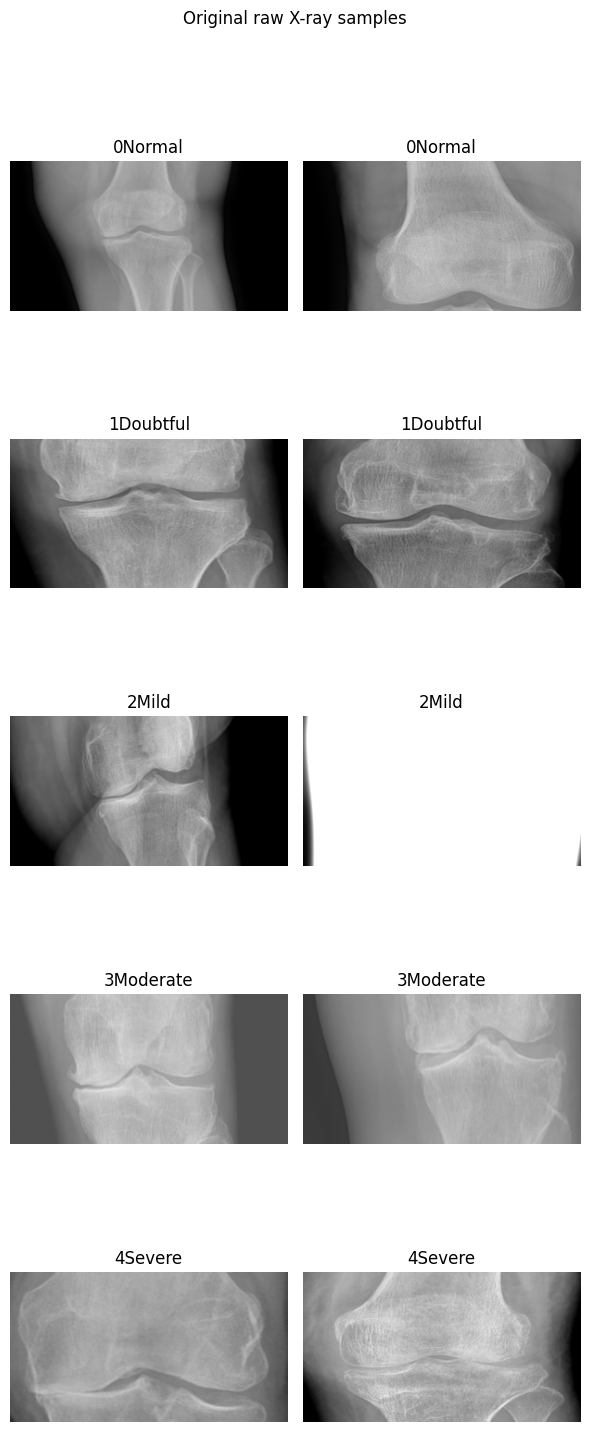

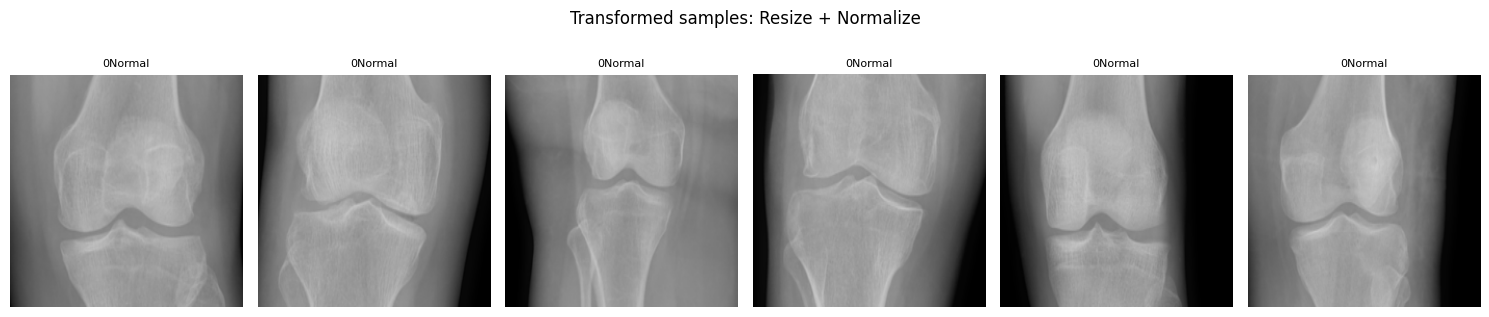

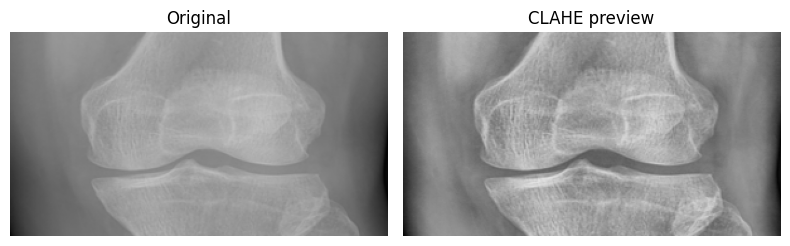

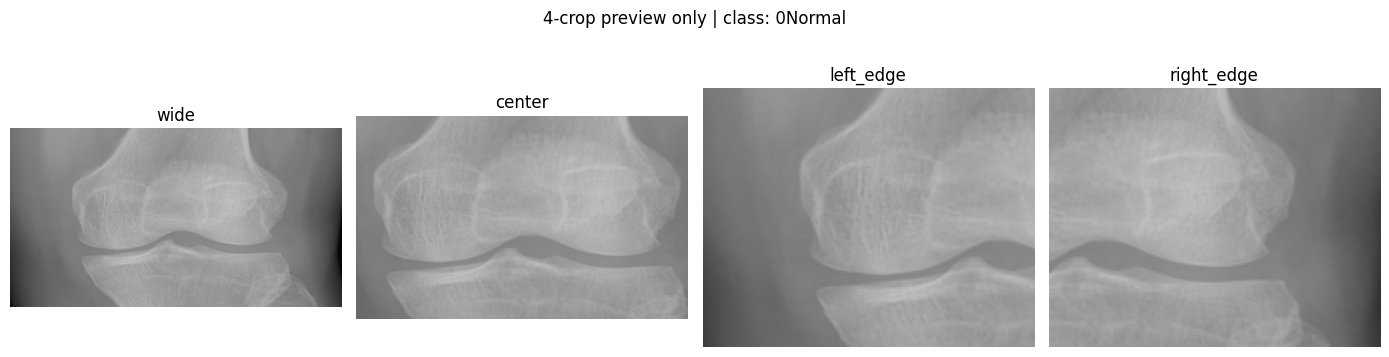

In [7]:
def denormalize_tensor(img_tensor, mean=NORMALIZE_MEAN, std=NORMALIZE_STD):
    img = img_tensor.detach().cpu().clone()
    mean_t = torch.tensor(mean).view(3, 1, 1)
    std_t = torch.tensor(std).view(3, 1, 1)
    img = img * std_t + mean_t
    img = img.clamp(0, 1)
    return img.permute(1, 2, 0).numpy()


def show_original_samples(dataset, n_per_class=2):
    samples_by_class = {i: [] for i in range(len(dataset.classes))}
    for path, label in dataset.samples:
        samples_by_class[label].append(path)

    rows = len(dataset.classes)
    cols = n_per_class
    plt.figure(figsize=(cols * 3, rows * 3))

    plot_idx = 1
    for class_idx, class_name in enumerate(dataset.classes):
        chosen = random.sample(samples_by_class[class_idx], min(n_per_class, len(samples_by_class[class_idx])))
        for img_path in chosen:
            img = Image.open(img_path).convert("L")
            plt.subplot(rows, cols, plot_idx)
            plt.imshow(img, cmap="gray", vmin=0, vmax=255)
            plt.title(class_name)
            plt.axis("off")
            plot_idx += 1

    plt.suptitle("Original raw X-ray samples", y=1.01)
    plt.tight_layout()
    plt.show()


def show_transformed_samples(dataset, n=6):
    plt.figure(figsize=(n * 2.5, 3))
    for i in range(n):
        img_tensor, label = dataset[i]
        img_np = denormalize_tensor(img_tensor)
        plt.subplot(1, n, i + 1)
        plt.imshow(img_np)
        plt.title(dataset.classes[label], fontsize=8)
        plt.axis("off")
    plt.suptitle("Transformed samples: Resize + Normalize", y=1.05)
    plt.tight_layout()
    plt.show()


def show_clahe_preview(dataset, index=0):
    img_path, label = dataset.samples[index]
    img = Image.open(img_path).convert("RGB")
    clahe_img = apply_clahe_pil(img)

    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(img.convert("L"), cmap="gray", vmin=0, vmax=255)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(clahe_img.convert("L"), cmap="gray", vmin=0, vmax=255)
    plt.title("CLAHE preview" if CV2_AVAILABLE else "CLAHE unavailable")
    plt.axis("off")
    plt.tight_layout()
    plt.show()


def make_crop_box(width, height, center_x_ratio, center_y_ratio, width_ratio, height_ratio):
    crop_w = max(1, int(width * width_ratio))
    crop_h = max(1, int(height * height_ratio))
    cx = int(width * center_x_ratio)
    cy = int(height * center_y_ratio)

    left = cx - crop_w // 2
    top = cy - crop_h // 2
    left = max(0, min(left, width - crop_w))
    top = max(0, min(top, height - crop_h))
    return (left, top, left + crop_w, top + crop_h)


def show_4crop_preview(dataset, index=0):
    img_path, label = dataset.samples[index]
    img = Image.open(img_path).convert("RGB")
    w, h = img.size

    crop_specs = [
        ("wide", None),
        ("center", make_crop_box(w, h, 0.50, 0.50, 0.70, 0.80)),
        ("left_edge", make_crop_box(w, h, 0.30, 0.50, 0.55, 0.80)),
        ("right_edge", make_crop_box(w, h, 0.70, 0.50, 0.55, 0.80)),
    ]

    plt.figure(figsize=(14, 4))
    for i, (name, box) in enumerate(crop_specs, start=1):
        crop = img if box is None else img.crop(box)
        plt.subplot(1, 4, i)
        plt.imshow(crop.convert("L"), cmap="gray", vmin=0, vmax=255)
        plt.title(name)
        plt.axis("off")
    plt.suptitle(f"4-crop preview only | class: {dataset.classes[label]}")
    plt.tight_layout()
    plt.show()


show_original_samples(raw_train, n_per_class=2)
show_transformed_samples(train_dataset, n=6)
show_clahe_preview(raw_train, index=0)
show_4crop_preview(raw_train, index=0)

## 8. Model Definition

This experiment uses **single-image DenseNet121**.

Only the final classifier is replaced for 5-class knee OA grading.

In [8]:
def build_densenet121(num_classes=5, dropout=0.3):
    weights = models.DenseNet121_Weights.DEFAULT
    model = models.densenet121(weights=weights)

    in_features = model.classifier.in_features
    model.classifier = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(in_features, num_classes)
    )

    return model.to(device)


# Build one sample model to verify architecture.
sample_model = build_densenet121(num_classes=NUM_CLASSES, dropout=CONFIG["DROPOUT"])
print(sample_model.classifier)
del sample_model
torch.cuda.empty_cache()

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 177MB/s]


Sequential(
  (0): Dropout(p=0.3, inplace=False)
  (1): Linear(in_features=1024, out_features=5, bias=True)
)


## 9. Loss Function

The selected loss is **Class-weighted HybridChenOrdinalLoss**.

It combines:

```text
CrossEntropyLoss with class weights
+
alpha × Chen-style ordinal penalty
```

This is used because knee OA severity grades are ordered, and large grading mistakes should be penalized more strongly.

In [9]:
class HybridChenOrdinalLoss(nn.Module):
    """
    Class-weighted Hybrid Chen-style ordinal loss.

    total_loss = weighted_CE + alpha * ordinal_penalty
    """
    def __init__(
        self,
        num_classes=5,
        class_weights=None,
        alpha=0.10,
        penalty_distance=2,
        square_loss=False,
        normalize=True,
    ):
        super().__init__()

        self.num_classes = num_classes
        self.alpha = alpha
        self.penalty_distance = penalty_distance
        self.square_loss = square_loss
        self.normalize = normalize

        self.ce_loss = nn.CrossEntropyLoss(weight=class_weights)

        penalty_matrix = self._create_penalty_matrix(
            num_classes=num_classes,
            penalty_distance=penalty_distance,
            normalize=normalize,
        )

        self.register_buffer("penalty_matrix", penalty_matrix)

        self.last_ce_loss = None
        self.last_ordinal_penalty = None
        self.last_total_loss = None

    def _create_penalty_matrix(self, num_classes, penalty_distance, normalize):
        class_indices = torch.arange(num_classes, dtype=torch.float32)
        distance_matrix = torch.abs(
            class_indices.unsqueeze(0) - class_indices.unsqueeze(1)
        )

        # Chen-style modified penalty:
        # distance 1 -> 3, distance 2 -> 5, distance 3 -> 7, distance 4 -> 9
        penalty_matrix = distance_matrix * penalty_distance + 1.0
        penalty_matrix[distance_matrix == 0] = 0.0

        if normalize:
            max_value = penalty_matrix.max()
            if max_value > 0:
                penalty_matrix = penalty_matrix / max_value

        return penalty_matrix

    def forward(self, logits, targets, return_parts=False):
        ce = self.ce_loss(logits, targets)

        probabilities = torch.softmax(logits, dim=1)
        penalty_matrix = self.penalty_matrix.to(logits.device)
        target_penalties = penalty_matrix[targets.long()]

        penalty_per_sample = torch.sum(probabilities * target_penalties, dim=1)

        if self.square_loss:
            penalty_per_sample = penalty_per_sample ** 2

        ordinal_penalty = torch.mean(penalty_per_sample)
        total_loss = ce + self.alpha * ordinal_penalty

        self.last_ce_loss = ce.detach()
        self.last_ordinal_penalty = ordinal_penalty.detach()
        self.last_total_loss = total_loss.detach()

        if return_parts:
            return total_loss, ce, ordinal_penalty

        return total_loss


criterion_preview = HybridChenOrdinalLoss(
    num_classes=NUM_CLASSES,
    class_weights=class_weights,
    alpha=CONFIG["ORDINAL_ALPHA"],
    penalty_distance=CONFIG["PENALTY_DISTANCE"],
    square_loss=CONFIG["SQUARE_LOSS"],
    normalize=CONFIG["NORMALIZE_MATRIX"],
).to(device)

print("Hybrid Chen penalty matrix:")
print(criterion_preview.penalty_matrix.cpu().numpy())
print("\nClass weights:")
print(class_weights.detach().cpu().numpy())
del criterion_preview

Hybrid Chen penalty matrix:
[[0.         0.33333334 0.5555556  0.7777778  1.        ]
 [0.33333334 0.         0.33333334 0.5555556  0.7777778 ]
 [0.5555556  0.33333334 0.         0.33333334 0.5555556 ]
 [0.7777778  0.5555556  0.33333334 0.         0.33333334]
 [1.         0.7777778  0.5555556  0.33333334 0.        ]]

Class weights:
[0.6481013  0.66493505 1.5283582  1.6786885  1.4222223 ]


## 10. Optimizer & Scheduler

Each configuration uses AdamW and a StepLR scheduler.

In [10]:
def build_optimizer_scheduler(model, lr, weight_decay=0.0):
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
    )

    scheduler = torch.optim.lr_scheduler.StepLR(
        optimizer,
        step_size=10,
        gamma=0.5,
    )

    return optimizer, scheduler

print("Optimizer: AdamW")
print("Scheduler: StepLR(step_size=10, gamma=0.5)")

Optimizer: AdamW
Scheduler: StepLR(step_size=10, gamma=0.5)


## 11. Training Loop

The training loop records:

- train loss
- validation loss
- validation QWK
- validation MAE

The best checkpoint is selected using validation QWK.

In [11]:
def compute_metrics(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    qwk = cohen_kappa_score(y_true, y_pred, weights="quadratic")
    mae = np.mean(np.abs(y_true - y_pred))

    diff = np.abs(y_true - y_pred)
    total_errors = int(np.sum(diff > 0))
    adjacent_errors = int(np.sum(diff == 1))
    distant_errors = int(np.sum(diff >= 2))

    return {
        "accuracy": float(acc),
        "macro_f1": float(macro_f1),
        "weighted_f1": float(weighted_f1),
        "qwk": float(qwk),
        "mae": float(mae),
        "total_errors": total_errors,
        "adjacent_errors": adjacent_errors,
        "distant_errors": distant_errors,
    }


def train_one_epoch(model, loader, criterion, optimizer, scaler=None, desc="train"):
    model.train()

    running_loss = 0.0
    running_ce = 0.0
    running_ord = 0.0
    y_true, y_pred = [], []

    use_amp = scaler is not None and device.type == "cuda"

    for images, labels in tqdm(loader, desc=desc, leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        amp_context = torch.amp.autocast("cuda", enabled=use_amp) if device.type == "cuda" else nullcontext()

        with amp_context:
            logits = model(images)
            loss, ce_loss, ordinal_penalty = criterion(logits, labels, return_parts=True)

        if use_amp:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size
        running_ce += ce_loss.item() * batch_size
        running_ord += ordinal_penalty.item() * batch_size

        preds = logits.detach().argmax(dim=1)
        y_true.extend(labels.detach().cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

    metrics = compute_metrics(y_true, y_pred)
    metrics["loss"] = running_loss / len(loader.dataset)
    metrics["ce_loss"] = running_ce / len(loader.dataset)
    metrics["ordinal_penalty"] = running_ord / len(loader.dataset)

    return metrics


@torch.no_grad()
def evaluate_model(model, loader, criterion, desc="eval"):
    model.eval()

    running_loss = 0.0
    running_ce = 0.0
    running_ord = 0.0
    y_true, y_pred = [], []
    y_prob = []

    for images, labels in tqdm(loader, desc=desc, leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        logits = model(images)
        loss, ce_loss, ordinal_penalty = criterion(logits, labels, return_parts=True)

        probs = torch.softmax(logits, dim=1)
        preds = logits.argmax(dim=1)

        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size
        running_ce += ce_loss.item() * batch_size
        running_ord += ordinal_penalty.item() * batch_size

        y_true.extend(labels.detach().cpu().numpy())
        y_pred.extend(preds.detach().cpu().numpy())
        y_prob.extend(probs.detach().cpu().numpy())

    metrics = compute_metrics(y_true, y_pred)
    metrics["loss"] = running_loss / len(loader.dataset)
    metrics["ce_loss"] = running_ce / len(loader.dataset)
    metrics["ordinal_penalty"] = running_ord / len(loader.dataset)

    return metrics, np.array(y_true), np.array(y_pred), np.array(y_prob)


def train_experiment(cfg):
    print("=" * 80)
    print("Running config:", cfg["name"])
    print(cfg)

    set_seed(CONFIG["SEED"])

    train_loader, val_loader, test_loader, train_dataset, val_dataset, test_dataset = build_dataloaders_for_config(cfg)

    model = build_densenet121(
        num_classes=NUM_CLASSES,
        dropout=cfg["dropout"],
    )

    criterion = HybridChenOrdinalLoss(
        num_classes=NUM_CLASSES,
        class_weights=class_weights,
        alpha=cfg["ordinal_alpha"],
        penalty_distance=CONFIG["PENALTY_DISTANCE"],
        square_loss=CONFIG["SQUARE_LOSS"],
        normalize=CONFIG["NORMALIZE_MATRIX"],
    ).to(device)

    optimizer, scheduler = build_optimizer_scheduler(
        model,
        lr=cfg["lr"],
        weight_decay=CONFIG["WEIGHT_DECAY"],
    )

    scaler = torch.amp.GradScaler("cuda", enabled=(CONFIG["USE_AMP"] and device.type == "cuda"))

    cfg_dir = RESULTS_DIR / cfg["name"]
    cfg_fig_dir = FIGURES_DIR / cfg["name"]
    cfg_model_path = MODELS_DIR / f"{cfg['name']}_best.pth"
    cfg_dir.mkdir(parents=True, exist_ok=True)
    cfg_fig_dir.mkdir(parents=True, exist_ok=True)

    best_val_qwk = -999.0
    best_epoch = -1
    best_state = None
    no_improve = 0
    history = []

    start_time = time.time()

    for epoch in range(1, CONFIG["EPOCHS"] + 1):
        print(f"\nEpoch {epoch}/{CONFIG['EPOCHS']} | {cfg['name']}")

        train_metrics = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler=scaler, desc="train"
        )
        val_metrics, _, _, _ = evaluate_model(
            model, val_loader, criterion, desc="val"
        )

        scheduler.step()

        row = {
            "epoch": epoch,
            "config": cfg["name"],
            "train_loss": train_metrics["loss"],
            "train_ce_loss": train_metrics["ce_loss"],
            "train_ordinal_penalty": train_metrics["ordinal_penalty"],
            "train_qwk": train_metrics["qwk"],
            "val_loss": val_metrics["loss"],
            "val_ce_loss": val_metrics["ce_loss"],
            "val_ordinal_penalty": val_metrics["ordinal_penalty"],
            "val_accuracy": val_metrics["accuracy"],
            "val_macro_f1": val_metrics["macro_f1"],
            "val_qwk": val_metrics["qwk"],
            "val_mae": val_metrics["mae"],
            "val_adjacent_errors": val_metrics["adjacent_errors"],
            "val_distant_errors": val_metrics["distant_errors"],
        }
        history.append(row)

        print(
            f"train_loss={train_metrics['loss']:.4f} | "
            f"val_loss={val_metrics['loss']:.4f} | "
            f"val_acc={val_metrics['accuracy']:.4f} | "
            f"val_macro_f1={val_metrics['macro_f1']:.4f} | "
            f"val_qwk={val_metrics['qwk']:.4f} | "
            f"val_mae={val_metrics['mae']:.4f} | "
            f"val_distant={val_metrics['distant_errors']}"
        )

        if val_metrics["qwk"] > best_val_qwk:
            best_val_qwk = val_metrics["qwk"]
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            torch.save(best_state, cfg_model_path)
            no_improve = 0
            print(f"New best val QWK: {best_val_qwk:.4f}")
        else:
            no_improve += 1
            print(f"No improvement: {no_improve}/{CONFIG['PATIENCE']}")

        if no_improve >= CONFIG["PATIENCE"]:
            print("Early stopping.")
            break

    elapsed = time.time() - start_time

    history_df = pd.DataFrame(history)
    history_df.to_csv(cfg_dir / "history.csv", index=False)

    # Load best model and test.
    model.load_state_dict(torch.load(cfg_model_path, map_location=device))
    test_metrics, test_true, test_pred, test_prob = evaluate_model(
        model, test_loader, criterion, desc="test"
    )

    summary = {
        "config": cfg,
        "best_epoch": int(best_epoch),
        "best_val_qwk": float(best_val_qwk),
        "elapsed_seconds": float(elapsed),
        "test_metrics": test_metrics,
        "model_path": str(cfg_model_path),
    }

    with open(cfg_dir / "summary.json", "w") as f:
        json.dump(summary, f, indent=2)

    np.save(cfg_dir / "test_true.npy", test_true)
    np.save(cfg_dir / "test_pred.npy", test_pred)
    np.save(cfg_dir / "test_prob.npy", test_prob)

    print("\nTest metrics for", cfg["name"])
    print(json.dumps(test_metrics, indent=2))

    return {
        "cfg": cfg,
        "model": model,
        "criterion": criterion,
        "test_loader": test_loader,
        "test_dataset": test_dataset,
        "history_df": history_df,
        "test_metrics": test_metrics,
        "test_true": test_true,
        "test_pred": test_pred,
        "test_prob": test_prob,
        "summary": summary,
        "cfg_dir": cfg_dir,
        "cfg_fig_dir": cfg_fig_dir,
        "cfg_model_path": cfg_model_path,
    }


all_results = []
for cfg in EXPERIMENT_CONFIGS:
    result = train_experiment(cfg)
    all_results.append(result)
    torch.cuda.empty_cache()

Running config: no_aug_224
{'name': 'no_aug_224', 'img_size': 224, 'batch_size': 16, 'use_aug': False, 'use_clahe': False, 'lr': 0.0001, 'dropout': 0.3, 'ordinal_alpha': 0.1}

Epoch 1/30 | no_aug_224


train:   0%|          | 0/64 [00:00<?, ?it/s]

val:   0%|          | 0/10 [00:00<?, ?it/s]

train_loss=1.2928 | val_loss=0.8697 | val_acc=0.7055 | val_macro_f1=0.6710 | val_qwk=0.8574 | val_mae=0.3836 | val_distant=11
New best val QWK: 0.8574

Epoch 2/30 | no_aug_224


train:   0%|          | 0/64 [00:00<?, ?it/s]

...

train:   0%|          | 0/64 [00:00<?, ?it/s]

val:   0%|          | 0/10 [00:00<?, ?it/s]

train_loss=0.0895 | val_loss=0.4862 | val_acc=0.8425 | val_macro_f1=0.8415 | val_qwk=0.9261 | val_mae=0.1918 | val_distant=3
No improvement: 7/7
Early stopping.


test:   0%|          | 0/19 [00:00<?, ?it/s]


Test metrics for light_aug_320
{
  "accuracy": 0.7959183673469388,
  "macro_f1": 0.7936762068029523,
  "weighted_f1": 0.7966965724241692,
  "qwk": 0.8854898219213652,
  "mae": 0.2687074829931973,
  "total_errors": 60,
  "adjacent_errors": 47,
  "distant_errors": 13,
  "loss": 0.6163200875427447,
  "ce_loss": 0.6060925694499292,
  "ordinal_penalty": 0.1022752034446212
}


## 12. Validation Section

Validation is used during training to select the best checkpoint by QWK.

This cell summarizes validation history for all preprocessing settings.

In [12]:
validation_rows = []
for result in all_results:
    hist = result["history_df"]
    best_row = hist.loc[hist["val_qwk"].idxmax()].to_dict()
    validation_rows.append({
        "config": result["cfg"]["name"],
        "best_epoch": int(best_row["epoch"]),
        "best_val_qwk": best_row["val_qwk"],
        "best_val_accuracy": best_row["val_accuracy"],
        "best_val_macro_f1": best_row["val_macro_f1"],
        "best_val_mae": best_row["val_mae"],
        "best_val_distant_errors": best_row["val_distant_errors"],
    })

validation_summary_df = pd.DataFrame(validation_rows).sort_values("best_val_qwk", ascending=False)
display(validation_summary_df)

validation_summary_df.to_csv(RESULTS_DIR / "validation_summary.csv", index=False)

,config,best_epoch,best_val_qwk,best_val_accuracy,best_val_macro_f1,best_val_mae,best_val_distant_errors
1,light_aug_224,19,0.948868,0.835616,0.827200,0.178082,2
2,light_aug_320,17,0.946687,0.835616,0.839163,0.178082,2
0,no_aug_224,3,0.902388,0.767123,0.770406,0.273973,4


## 13. Test Evaluation

The final test evaluation reports:

- Accuracy
- Macro F1
- Weighted F1
- QWK
- MAE

In [13]:
test_rows = []
for result in all_results:
    m = result["test_metrics"]
    test_rows.append({
        "config": result["cfg"]["name"],
        "best_epoch": result["summary"]["best_epoch"],
        "best_val_qwk": result["summary"]["best_val_qwk"],
        "test_accuracy": m["accuracy"],
        "test_macro_f1": m["macro_f1"],
        "test_weighted_f1": m["weighted_f1"],
        "test_qwk": m["qwk"],
        "test_mae": m["mae"],
        "test_total_errors": m["total_errors"],
        "test_adjacent_errors": m["adjacent_errors"],
        "test_distant_errors": m["distant_errors"],
    })

test_summary_df = pd.DataFrame(test_rows).sort_values("test_qwk", ascending=False)
display(test_summary_df)

test_summary_df.to_csv(RESULTS_DIR / "test_summary.csv", index=False)

best_result = all_results[
    int(np.argmax([r["test_metrics"]["qwk"] for r in all_results]))
]

print("Best test config:", best_result["cfg"]["name"])
print(json.dumps(best_result["test_metrics"], indent=2))

,config,best_epoch,best_val_qwk,test_accuracy,test_macro_f1,test_weighted_f1,test_qwk,test_mae,test_total_errors,test_adjacent_errors,test_distant_errors
1,light_aug_224,19,0.948868,0.795918,0.788969,0.797170,0.892376,0.261905,60,48,12
2,light_aug_320,17,0.946687,0.795918,0.793676,0.796697,0.885490,0.268707,60,47,13
0,no_aug_224,3,0.902388,0.741497,0.745149,0.736154,0.839306,0.353741,76,57,19


Best test config: light_aug_224
{
  "accuracy": 0.7959183673469388,
  "macro_f1": 0.7889685951280154,
  "weighted_f1": 0.7971698017419205,
  "qwk": 0.8923756406211868,
  "mae": 0.2619047619047619,
  "total_errors": 60,
  "adjacent_errors": 48,
  "distant_errors": 12,
  "loss": 0.7053196252811522,
  "ce_loss": 0.6954441704109412,
  "ordinal_penalty": 0.09875450797733806
}


### 13.1 Per-class Recall and F1

Class-wise recall and F1 are important because the model may perform differently across OA severity levels.

In [14]:
classwise_rows = []

for result in all_results:
    report = classification_report(
        result["test_true"],
        result["test_pred"],
        target_names=class_names,
        output_dict=True,
        zero_division=0,
    )

    for class_name in class_names:
        classwise_rows.append({
            "config": result["cfg"]["name"],
            "class_name": class_name,
            "precision": report[class_name]["precision"],
            "recall": report[class_name]["recall"],
            "f1_score": report[class_name]["f1-score"],
            "support": report[class_name]["support"],
        })

classwise_df = pd.DataFrame(classwise_rows)
display(classwise_df)

classwise_df.to_csv(RESULTS_DIR / "classwise_recall_f1.csv", index=False)

print("Classification report for best test config:")
print(classification_report(
    best_result["test_true"],
    best_result["test_pred"],
    target_names=class_names,
    zero_division=0,
))

,config,class_name,precision,recall,f1_score,support
0,no_aug_224,0Normal,0.912281,0.571429,0.702703,91.0
1,no_aug_224,1Doubtful,0.631148,0.875000,0.733333,88.0
2,no_aug_224,2Mild,0.666667,0.526316,0.588235,38.0
3,no_aug_224,3Moderate,0.794872,0.885714,0.837838,35.0
4,no_aug_224,4Severe,0.826087,0.904762,0.863636,42.0
5,light_aug_224,0Normal,0.838710,0.857143,0.847826,91.0
6,light_aug_224,1Doubtful,0.802469,0.738636,0.769231,88.0
7,light_aug_224,2Mild,0.604651,0.684211,0.641975,38.0
8,light_aug_224,3Moderate,0.769231,0.857143,0.810811,35.0
9,light_aug_224,4Severe,0.921053,0.833333,0.875000,42.0


Classification report for best test config:
              precision    recall  f1-score   support

     0Normal       0.84      0.86      0.85        91
   1Doubtful       0.80      0.74      0.77        88
       2Mild       0.60      0.68      0.64        38
   3Moderate       0.77      0.86      0.81        35
     4Severe       0.92      0.83      0.88        42

    accuracy                           0.80       294
   macro avg       0.79      0.79      0.79       294
weighted avg       0.80      0.80      0.80       294



## 14. Confusion Matrix

The confusion matrix shows which OA grades are commonly confused.

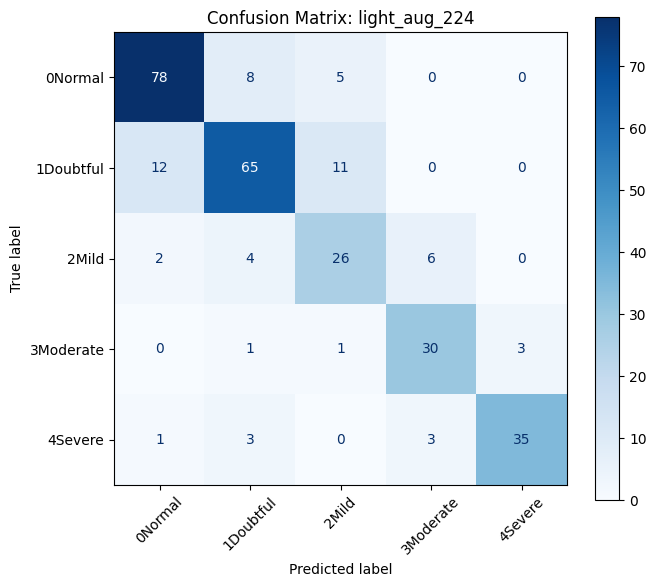

In [15]:
def plot_and_save_confusion_matrix(y_true, y_pred, title, save_path):
    cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(7, 6))

    if ConfusionMatrixDisplay is not None:
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
        disp.plot(ax=ax, cmap="Blues", values_format="d", xticks_rotation=45)
    else:
        ax.imshow(cm, cmap="Blues")
        ax.set_xticks(range(len(class_names)))
        ax.set_yticks(range(len(class_names)))
        ax.set_xticklabels(class_names, rotation=45, ha="right")
        ax.set_yticklabels(class_names)
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                ax.text(j, i, str(cm[i, j]), ha="center", va="center")
        ax.set_xlabel("Predicted label")
        ax.set_ylabel("True label")

    plt.title(title)
    plt.tight_layout()
    fig.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()

    return cm


best_cm = plot_and_save_confusion_matrix(
    best_result["test_true"],
    best_result["test_pred"],
    title=f"Confusion Matrix: {best_result['cfg']['name']}",
    save_path=FIGURES_DIR / "best_confusion_matrix.png",
)

pd.DataFrame(best_cm, index=class_names, columns=class_names).to_csv(
    RESULTS_DIR / "best_confusion_matrix.csv"
)

## 15. Error Analysis

For ordinal classification, adjacent and distant errors are more informative than total error alone.

- Adjacent error: predicted grade differs by 1
- Distant error: predicted grade differs by 2 or more

,dist_0_correct,dist_1_adjacent,dist_2,dist_3,dist_4,distant_errors,config
0,218,57,11,7,1,19,no_aug_224
1,234,48,8,3,1,12,light_aug_224
2,234,47,7,6,0,13,light_aug_320


Misclassified raw images for best config:
Wrong samples: 60 / 294


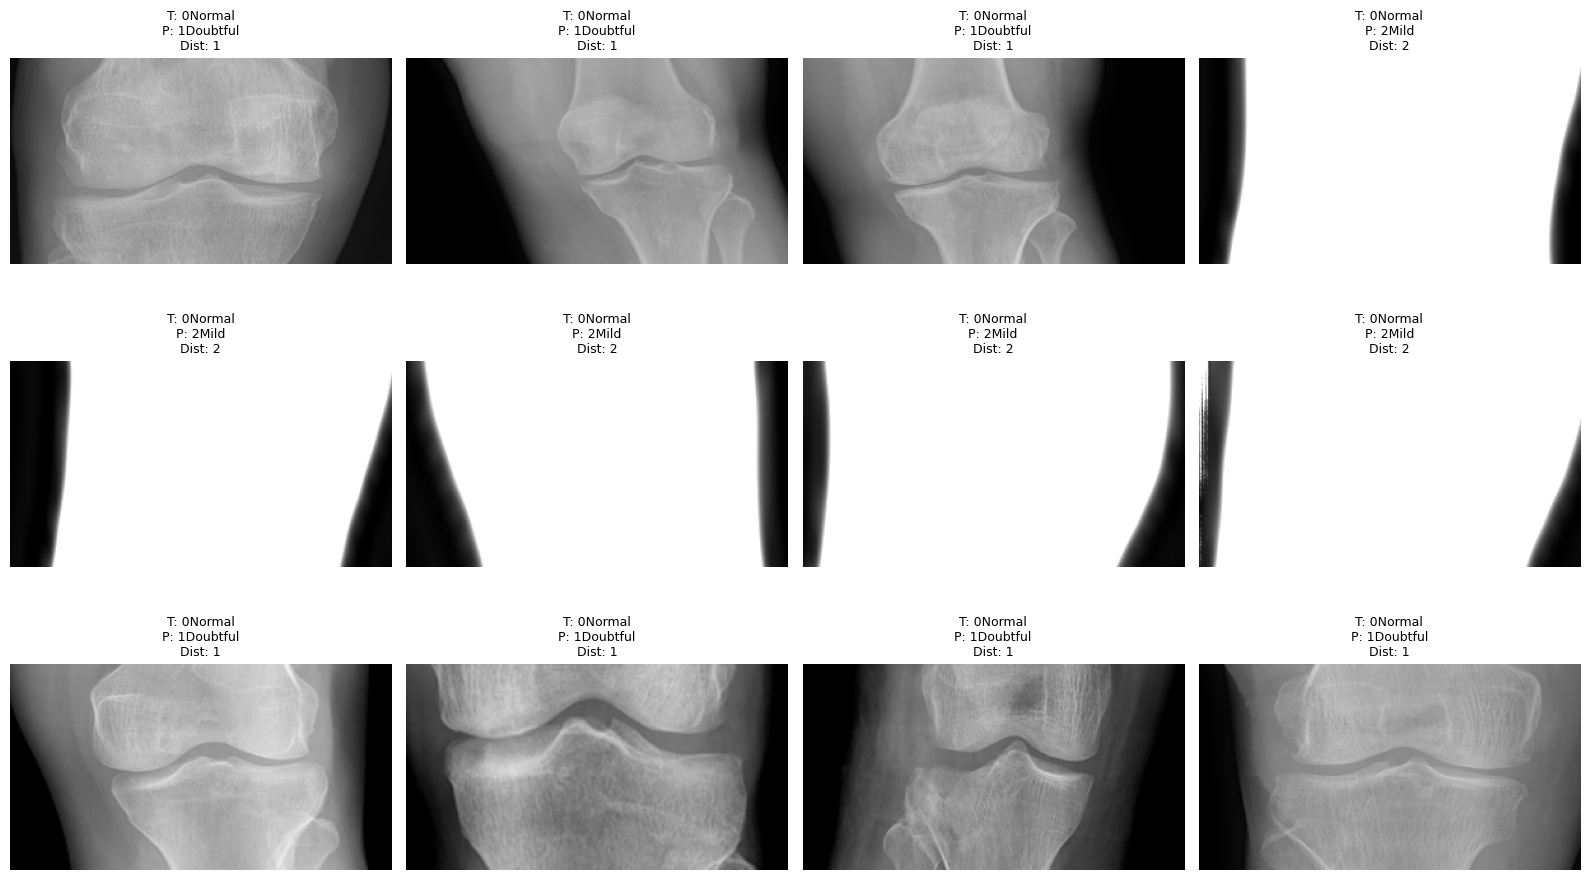

In [16]:
error_rows = []

for result in all_results:
    y_true = result["test_true"]
    y_pred = result["test_pred"]
    diff = np.abs(y_true - y_pred)

    counts = {
        "dist_0_correct": int(np.sum(diff == 0)),
        "dist_1_adjacent": int(np.sum(diff == 1)),
        "dist_2": int(np.sum(diff == 2)),
        "dist_3": int(np.sum(diff == 3)),
        "dist_4": int(np.sum(diff == 4)),
        "distant_errors": int(np.sum(diff >= 2)),
    }

    counts["config"] = result["cfg"]["name"]
    error_rows.append(counts)

error_analysis_df = pd.DataFrame(error_rows)
display(error_analysis_df)

error_analysis_df.to_csv(RESULTS_DIR / "error_analysis.csv", index=False)


def show_misclassified_raw_images(raw_dataset, y_true, y_pred, class_names, max_images=12):
    wrong_indices = [
        i for i, (t, p) in enumerate(zip(y_true, y_pred))
        if int(t) != int(p)
    ]

    print(f"Wrong samples: {len(wrong_indices)} / {len(y_true)}")
    show_indices = wrong_indices[:max_images]

    cols = 4
    rows = math.ceil(len(show_indices) / cols)
    plt.figure(figsize=(cols * 4, rows * 3.2))

    for plot_i, idx in enumerate(show_indices, start=1):
        img_path, true_label_from_dataset = raw_dataset.samples[idx]
        true_label = int(y_true[idx])
        pred_label = int(y_pred[idx])
        dist = abs(true_label - pred_label)

        img = Image.open(img_path).convert("L")

        plt.subplot(rows, cols, plot_i)
        plt.imshow(img, cmap="gray", vmin=0, vmax=255)
        plt.axis("off")
        plt.title(
            f"T: {class_names[true_label]}\nP: {class_names[pred_label]}\nDist: {dist}",
            fontsize=9
        )

    plt.tight_layout()
    plt.show()


print("Misclassified raw images for best config:")
show_misclassified_raw_images(
    raw_dataset=raw_test,
    y_true=best_result["test_true"],
    y_pred=best_result["test_pred"],
    class_names=class_names,
    max_images=12,
)

## 16. Grad-CAM

Grad-CAM is used to visually inspect whether the model focuses on clinically meaningful knee regions.

This section displays one correct and one incorrect prediction.

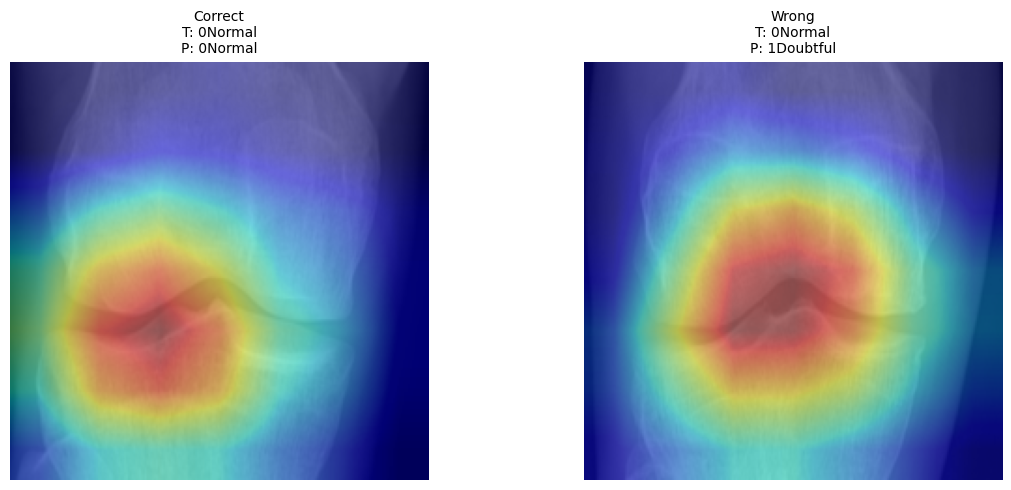

Saved Grad-CAM examples to: /kaggle/working/experiment05_preprocessing_aug_imgsize_classweighted_hybridchen/figures/best_gradcam_examples.png


In [17]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None

        self.forward_hook = target_layer.register_forward_hook(self._forward_hook)
        self.backward_hook = target_layer.register_full_backward_hook(self._backward_hook)

    def _forward_hook(self, module, input, output):
        self.activations = output.detach()

    def _backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def remove_hooks(self):
        self.forward_hook.remove()
        self.backward_hook.remove()

    def generate(self, image_tensor, class_idx=None):
        self.model.eval()
        self.model.zero_grad(set_to_none=True)

        image_tensor = image_tensor.unsqueeze(0).to(device)
        logits = self.model(image_tensor)

        if class_idx is None:
            class_idx = logits.argmax(dim=1).item()

        score = logits[:, class_idx]
        score.backward()

        gradients = self.gradients
        activations = self.activations

        weights = gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * activations).sum(dim=1).squeeze(0)
        cam = torch.relu(cam)

        cam = cam.detach().cpu().numpy()
        cam = cam - cam.min()
        if cam.max() > 0:
            cam = cam / cam.max()

        return cam, class_idx


def overlay_gradcam_on_image(img_np, cam, alpha=0.45):
    # Resize CAM to image size
    if CV2_AVAILABLE:
        cam_resized = cv2.resize(cam, (img_np.shape[1], img_np.shape[0]))
        heatmap = plt.get_cmap("jet")(cam_resized)[:, :, :3]
        overlay = (1 - alpha) * img_np + alpha * heatmap
        overlay = np.clip(overlay, 0, 1)
        return overlay
    else:
        return img_np


def show_gradcam_examples(result):
    model = result["model"]
    test_dataset = result["test_dataset"]
    y_true = result["test_true"]
    y_pred = result["test_pred"]

    correct_indices = [i for i, (t, p) in enumerate(zip(y_true, y_pred)) if int(t) == int(p)]
    wrong_indices = [i for i, (t, p) in enumerate(zip(y_true, y_pred)) if int(t) != int(p)]

    chosen = []
    if correct_indices:
        chosen.append(("Correct", correct_indices[0]))
    if wrong_indices:
        chosen.append(("Wrong", wrong_indices[0]))

    if not chosen:
        print("No examples available for Grad-CAM.")
        return

    # DenseNet121 final convolutional feature block
    target_layer = model.features.denseblock4
    gradcam = GradCAM(model, target_layer)

    plt.figure(figsize=(6 * len(chosen), 5))

    for plot_i, (case_name, idx) in enumerate(chosen, start=1):
        img_tensor, label = test_dataset[idx]
        img_np = denormalize_tensor(img_tensor)

        cam, pred_class = gradcam.generate(img_tensor, class_idx=int(y_pred[idx]))
        overlay = overlay_gradcam_on_image(img_np, cam)

        plt.subplot(1, len(chosen), plot_i)
        plt.imshow(overlay)
        plt.axis("off")
        plt.title(
            f"{case_name}\nT: {class_names[int(y_true[idx])]}\nP: {class_names[int(y_pred[idx])]}",
            fontsize=10
        )

    plt.tight_layout()
    save_path = FIGURES_DIR / "best_gradcam_examples.png"
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()

    gradcam.remove_hooks()
    print("Saved Grad-CAM examples to:", save_path)


show_gradcam_examples(best_result)

## 17. Final Summary

# Experiment Conclusion

This experiment compared preprocessing, image size, and light augmentation settings after selecting:

- Single-image DenseNet121
- Class-weighted HybridChenOrdinalLoss

The main purpose was to test whether image-level preprocessing and light medical-image augmentation improve QWK, MAE, and distant grading errors before returning to multi-crop models.

After this experiment, the best preprocessing setting should be used for the next stage. If light augmentation or a larger image size improves QWK and reduces MAE / distant errors, that setting can be reused in the later 4-crop experiment.

If CLAHE is unstable, it should be reported as an attempted preprocessing method rather than selected as the final method.

In [18]:
best_name = best_result["cfg"]["name"]
best_metrics = best_result["test_metrics"]

print("# Experiment Conclusion")
print()
print(f"Best preprocessing configuration: {best_name}")
print(f"Test Accuracy: {best_metrics['accuracy']:.4f}")
print(f"Test Macro F1: {best_metrics['macro_f1']:.4f}")
print(f"Test Weighted F1: {best_metrics['weighted_f1']:.4f}")
print(f"Test QWK: {best_metrics['qwk']:.4f}")
print(f"Test MAE: {best_metrics['mae']:.4f}")
print(f"Adjacent errors: {best_metrics['adjacent_errors']}")
print(f"Distant errors: {best_metrics['distant_errors']}")
print()
print("This selected preprocessing setting can be carried forward to the next experiment.")

# Experiment Conclusion

Best preprocessing configuration: light_aug_224
Test Accuracy: 0.7959
Test Macro F1: 0.7890
Test Weighted F1: 0.7972
Test QWK: 0.8924
Test MAE: 0.2619
Adjacent errors: 48
Distant errors: 12

This selected preprocessing setting can be carried forward to the next experiment.


## 18. Save Results

This section saves:

- `metrics.json`
- `confusion_matrix.png`
- comparison CSV files
- best model summary

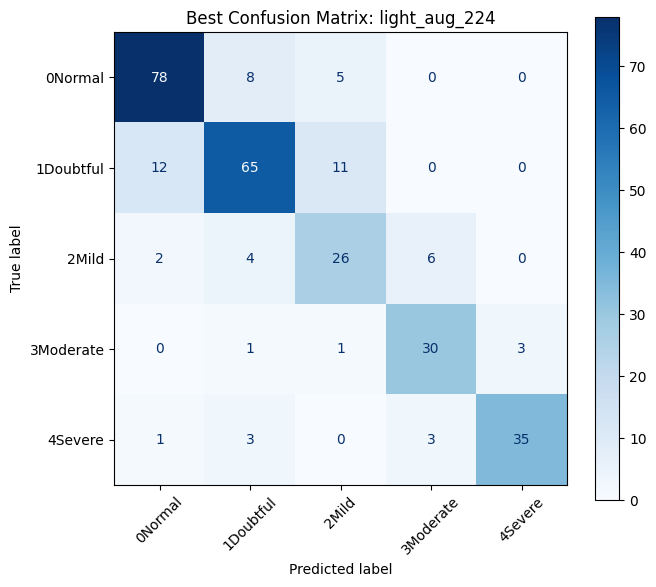

Saved results to: /kaggle/working/experiment05_preprocessing_aug_imgsize_classweighted_hybridchen/results
Saved figures to: /kaggle/working/experiment05_preprocessing_aug_imgsize_classweighted_hybridchen/figures
Main metrics file: /kaggle/working/experiment05_preprocessing_aug_imgsize_classweighted_hybridchen/results/metrics.json
Main confusion matrix: /kaggle/working/experiment05_preprocessing_aug_imgsize_classweighted_hybridchen/figures/confusion_matrix.png


In [19]:
final_metrics = {
    "experiment_name": EXPERIMENT_NAME,
    "config": CONFIG,
    "experiment_configs": EXPERIMENT_CONFIGS,
    "best_config": best_result["cfg"],
    "best_test_metrics": best_result["test_metrics"],
    "best_summary": best_result["summary"],
}

with open(RESULTS_DIR / "metrics.json", "w") as f:
    json.dump(final_metrics, f, indent=2)

# Save best confusion matrix image as required.
plot_and_save_confusion_matrix(
    best_result["test_true"],
    best_result["test_pred"],
    title=f"Best Confusion Matrix: {best_result['cfg']['name']}",
    save_path=FIGURES_DIR / "confusion_matrix.png",
)

# Also copy/record main comparison files.
test_summary_df.to_csv(RESULTS_DIR / "preprocessing_test_comparison.csv", index=False)
validation_summary_df.to_csv(RESULTS_DIR / "preprocessing_validation_comparison.csv", index=False)
classwise_df.to_csv(RESULTS_DIR / "preprocessing_classwise_recall_f1.csv", index=False)
error_analysis_df.to_csv(RESULTS_DIR / "preprocessing_error_analysis.csv", index=False)

print("Saved results to:", RESULTS_DIR)
print("Saved figures to:", FIGURES_DIR)
print("Main metrics file:", RESULTS_DIR / "metrics.json")
print("Main confusion matrix:", FIGURES_DIR / "confusion_matrix.png")